# Redes de Interacciones

Red de **interacción de personajes** de la temporada 1 de la serie de HBO Juego de Tronos.

Los personajes están conectados mediante aristas ponderadas por el **número de interacciones** de los personajes.

Datos disponibles en: https://github.com/mathbeveridge/gameofthrones

In [ ]:
!pip install numpy pandas networkx matplotlib

In [60]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [35]:
# datos
dat_nodes = pd.read_csv("got-s1-nodes.csv")
dat_edges = pd.read_csv("got-s1-edges.csv")

In [36]:
# grafo
got = nx.Graph()
got.add_nodes_from(dat_nodes['Id'])
for _, row in dat_edges.iterrows():
    got.add_edge(row.iloc[0], row.iloc[1], weight=row['Weight'])

In [37]:
# orden
print("Orden:", got.number_of_nodes())
# tamaño
print("Tamaño:", got.number_of_edges())
# dirigida?
print("Dirigida:", got.is_directed())
# ponderada?
print("Ponderada:", nx.is_weighted(got))

Orden: 126
Tamaño: 549
Dirigida: False
Ponderada: True


In [38]:
# matriz de adyacencia
nodes = list(got.nodes())
Y = nx.to_numpy_array(got, nodelist=nodes)

# grado
degree_dict = dict(got.degree())
degree_series = pd.Series(degree_dict)
row_sums = pd.Series(Y.sum(axis=1), index=nodes)
col_sums = pd.Series(Y.sum(axis=0), index=nodes)

comparison = pd.DataFrame({
    'degree': degree_series,
    'row_sum': row_sums,
    'col_sum': col_sums
})
print(comparison.head(5))

                degree  row_sum  col_sum
ADDAM_MARBRAND       3      8.0      8.0
AEGON                2      4.0      4.0
AERYS               13     41.0     41.0
ALLISER_THORNE       8     73.0     73.0
ARYA                28    373.0    373.0


In [39]:
# top 10 por grado
d = pd.Series(dict(got.degree()))
print(d.sort_values(ascending=False).head(10))

NED        57
TYRION     41
CATELYN    36
ROBERT     36
ROBB       30
CERSEI     29
ARYA       28
JOFFREY    27
JON        26
SANSA      26
dtype: int64


In [61]:
comparison["degree"].mean()

np.float64(8.714285714285714)

In [63]:
nx.density(got)

0.06971428571428571

In [69]:
# Encontrar los nodos extremos del diámetro
longest_pair = None
max_dist = 0

for source in got.nodes():
    lengths = nx.single_source_shortest_path_length(got, source)
    
    for target, dist in lengths.items():
        if dist > max_dist:
            max_dist = dist
            longest_pair = (source, target)

print("Nodos extremos:", longest_pair)

# Camino diámetro
camino_diametro = nx.shortest_path(
    got,
    source=longest_pair[0],
    target=longest_pair[1]
)

print("Camino diámetro:", camino_diametro)

Nodos extremos: ('IROGENIA', 'MELESSA')
Camino diámetro: ['IROGENIA', 'DOREAH', 'DAENERYS', 'NED', 'JON', 'SAM', 'MELESSA']


In [40]:
# fuerza (strength)
wd = pd.Series({n: sum(w for _, _, w in got.edges(n, data='weight', default=1)) for n in got.nodes()})
print(wd.sort_values(ascending=False).head(10))

NED             1290
TYRION           709
CATELYN          584
ROBERT           563
JON              535
DAENERYS         535
CERSEI           444
ROBB             424
SANSA            422
LITTLEFINGER     383
dtype: int64


In [73]:
# Transitividad global (clustering coefficient global)
trans_global = nx.transitivity(got)
print(f"Transitividad global: {trans_global:.4f}")

# Transitividad local (clustering coefficient por nodo)
trans_local = nx.clustering(got)
trans_local_series = pd.Series(trans_local)

print(f"\nTransitividad local promedio: {trans_local_series.mean():.4f}")

Transitividad global: 0.3833

Transitividad local promedio: 0.6297


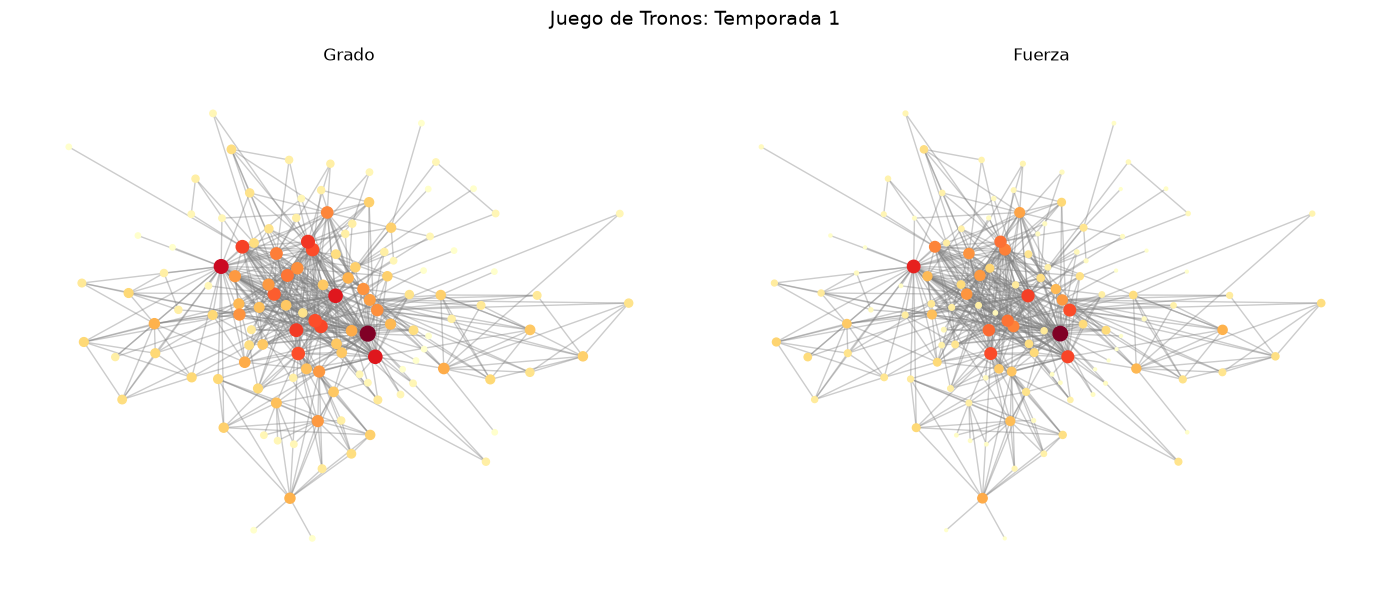

In [76]:
np.random.seed(123)
l = nx.kamada_kawai_layout(got)

d_got  = pd.Series(dict(got.degree()))
wd_got = pd.Series({n: sum(w for _, _, w in got.edges(n, data='weight', default=1)) for n in got.nodes()})

sizes_d = [1.5 * np.sqrt(d_got[n]) * 10 for n in got.nodes()]
sizes_w = [0.3 * np.sqrt(wd_got[n]) * 10 for n in got.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Juego de Tronos: Temporada 1", fontsize=14)

# usando el grado
nx.draw(got, pos=l, ax=axes[0],
        node_size=sizes_d,
        node_color=sizes_d,
        cmap=plt.cm.YlOrRd,
        edge_color=mcolors.to_rgba('gray', 0.4),
        with_labels=False)
axes[0].set_title("Grado")

# usando la fuerza
nx.draw(got, pos=l, ax=axes[1],
        node_size=sizes_w,
        node_color=sizes_w,
        cmap=plt.cm.YlOrRd,
        edge_color=mcolors.to_rgba('gray', 0.4),
        with_labels=False)
axes[1].set_title("Fuerza")

plt.tight_layout()
plt.show()